# Robotic Voice Effect

In this activity, you will build a robotic/metallic sound effect effect by combining audio with a waveform.

## How to Make a Robotic Sound Effect
The equation for this is:

$$y[n] = x[n] \bullet m[n]$$

where: 
- $x[n]$ is the current sound sample **(input)** 
- $m[n]$ is a repeating waveform (e.g. a sine wave)
- $y[n]$ is the **output**

### How does this work?
Multiplying your voice by a waveform rapidly changes its volume and distorts the natural shape of your voice which creates a robotic/metallic sound.

### What is this called?
This process is called amplitude modulation (AM).

It is the same idea used in AM radio, but here we are using it to create a sound effect instead of transmitting radio signals.

## Periodic Waveforms in FPGAs
Digital hardware like FPGAs cannot easily compute functions like cosine and sine in real time so we need to create a look-up table (LUT) of pre-computed values. 

For this workshop, we have provided a sine look-up table in `sine_lut.txt`. Each value in the file represents one point of a sine wave.

#### **Important: Scaling**
- Digital hardware cannot represent fractional values well, so all values in the LUT are scaled by $2^{15}$
- To bring it back to the correct range, you must shift right the output using `>>> 15` 
- If you forget this step, the output will sound very distorted


## Implementing the Robotic Module

Open `robotic.sv`. 

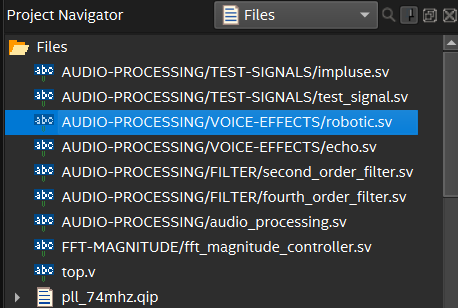

### Required signals
You will need the following signals: 
- `mult_result`: a variable to temporarily hold the unscaled multiplication result
- `lut`: an array to store the precomputed values from `sine_lut.txt`
- `index`: tracks the current position in the array 

### Reading Values from Text Files

You can read values from text files into your array `lut` with the following code:

```systemverilog
initial begin
  $readmemh("sine_lut.txt", lut);
end
```

### How the code matches the equation
Recall the robotic voice equation:
$$y[n] = x[n] \bullet m[n]$$

In the code: 
- `data_in` is $x[n]$, the current input sample
- `lut[index]` is the current part sine to mulitply, $m[n]$
- `data_out` is $y[n]$

### Starter Skeleton

If you are new to SystemVerilog syntax, you can use the reference sheet here: [SystemVerilog Reference Sheet](reference_sheet.ipynb)

You can use this skeleton to help you: 

```systemverilog
module robotic #(
    parameter SAMPLE_WIDTH = 16,
    parameter LUT_SIZE = 256
) (
    input  logic clk,
    input  logic reset,
    input  logic signed [SAMPLE_WIDTH-1:0] data_in,
    input  logic data_valid,
    output logic signed [SAMPLE_WIDTH-1:0] data_out
);

    // ------------------------------------------------------------------
    // Internal signals and registers
    // ------------------------------------------------------------------

    // TODO: create array for LUT (look-up table) values
    // TODO: create index variable 
    // TODO: create variable for the unscaled multiplication result


    // TODO: load LUT from text file

    // ------------------------------------------------------------------
    // Sequential logic
    // ------------------------------------------------------------------

    always_ff @(posedge clk or posedge reset) begin
        if (reset) begin
            // TODO: set index to 0

        end 
        else if (data_valid) begin
            // TODO: compute y[n] = x[n]*sin[n] without scaling
            // TODO: w

            // TODO: incredment the index
            // TODO: when the index reaches LUT_SIZE - 1, wrap it back to 0
        end
    end

endmodule
```

### Integration
Connect the `robotic` module inside `audio_processing` so the processed audio is sent to the output.

### Testing and validation

If it is correct you should hear your voice but with a metallic tone. You may also hear a constant tone alongside your own voice, this is expected behavior. You will be able to get rid of that tone when we learn about filters later in this workshop.


#### Optional: 

For debugging or just curiosity you can probe the output of the mic on the oscilloscope. You should see your voice following the shape of a sine wave.

##### Oscilloscope Settings 
- Press `Auto Scale`

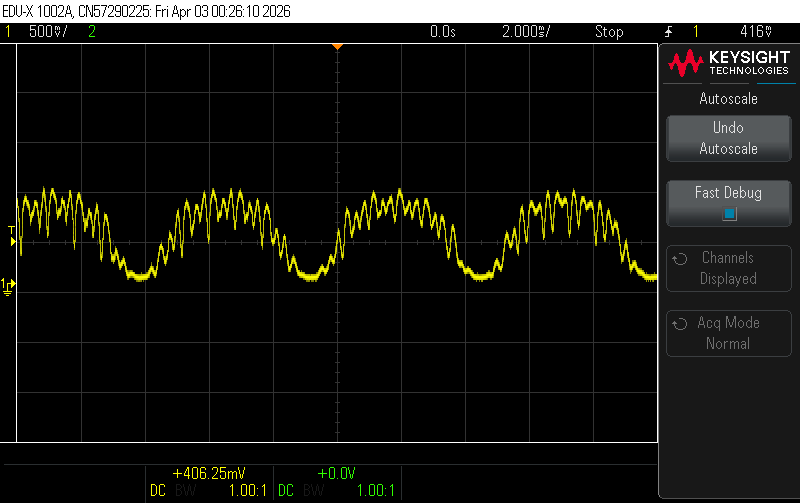

## Challenge

### 1. Turn the Effect On/Off
Inside `audio_processing`, add logic so you can turn the voice effect on and off using one of the switches on the board.

### 2. Try Different Waveforms

Replace the sine wave with:
- cosine in `cosine_lut.txt`
- triangle in `triangle_lut.txt`
- square in `square_lut.txt` (change `LUT_SIZE` to 512 for this one)

Notice how the sound and FFT change.

**Important:**

Some waveforms can produce a strong constant tone that may be loud and unpleasant. 

Consider lowering the volume (e.g., by scaling the audio using `>>> 1`) before sending it to the output, or be prepared to unplug your headphones when testing.

### 3. Combine Effects
Try combining  echoes with your robotic voice sound effect. 

Observe how they interact. 

---
|**Back:** [Echo Sound Effect](echo.ipynb) | [Top](#robotic-voice-effect)| **Next:** [Filters](filters.ipynb)|
|---------------------------------------|-------------------------------|------------------------------------------------------|
